# ResNet18 проти baseline

Ідея: взяти ImageNet-претренований ResNet18 (11.2M параметрів) і файнтюнити на спектрограмах. Очікування - він обійде SmallCNN з нуля (0.39M), бо фічі вже натреновані і параметрів набагато більше.

Планка від baseline (baseline_results.ipynb): window val F1 0.5115, track accuracy 0.623. Протокол однаковий: 5с вікна, AdamW + cosine, ваги класів у лоссі, чекпоінт по best val macro-F1.

In [1]:
import sys
sys.path.append('../src')

# Each run lives in data/runs/<name>: history.csv + best.pt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

from dataset import SpectrogramWindows
from models import build_model

RUNS_DIR = Path('../../data/runs')

def history(name):
    return pd.read_csv(RUNS_DIR / name / 'history.csv')

def plot_runs(runs, column, title, ylabel):
    plt.figure(figsize=(9, 5))
    for name in runs:
        h = history(name)
        plt.plot(h['epoch'], h[column], marker='o', markersize=3, label=name)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def evaluate_track_level(name):
    ckpt = torch.load(RUNS_DIR / name / 'best.pt', map_location='mps', weights_only=False)
    val = SpectrogramWindows('../../data/spectrograms', 'validation', normalize=ckpt['normalize'])
    model = build_model(ckpt.get('model_name', 'small_cnn'), len(val.classes)).to('mps')
    model.load_state_dict(ckpt['model'])
    model.eval()
    probs = []
    with torch.no_grad():
        for x, _ in DataLoader(val, batch_size=256):
            probs.append(torch.softmax(model(x.to('mps')), dim=1).cpu())
    probs = torch.cat(probs).numpy()
    win_true, win_pred = val.window_labels(), probs.argmax(axis=1)
    track_pos = np.array([pos for pos, _ in val.items])
    track_probs = np.stack([probs[track_pos == p].mean(axis=0)
                            for p in range(len(val.track_ids))])
    track_true, track_pred = val.track_labels, track_probs.argmax(axis=1)
    top3 = np.argsort(track_probs, axis=1)[:, -3:]
    return {'best_epoch': ckpt['epoch'],
            'win_f1': f1_score(win_true, win_pred, average='macro'),
            'track_acc': (track_pred == track_true).mean(),
            'track_f1': f1_score(track_true, track_pred, average='macro'),
            'track_top3_acc': np.any(top3 == track_true[:, None], axis=1).mean()}

print('runs on disk:', sorted(p.name for p in RUNS_DIR.iterdir() if (p / 'history.csv').exists()))

runs on disk: ['baseline', 'baseline_aug', 'resnet18_aug', 'resnet18_mixup', 'resnet18_vanilla']


## Файнтюн

Файнтюн усього ResNet18. lr 1e-4 замість 3e-4, щоб не зіпсувати претреновані ваги великими кроками. Перший conv перебудований під 1 канал (RGB-ядра усереднені), голова замінена на 14 класів з dropout.

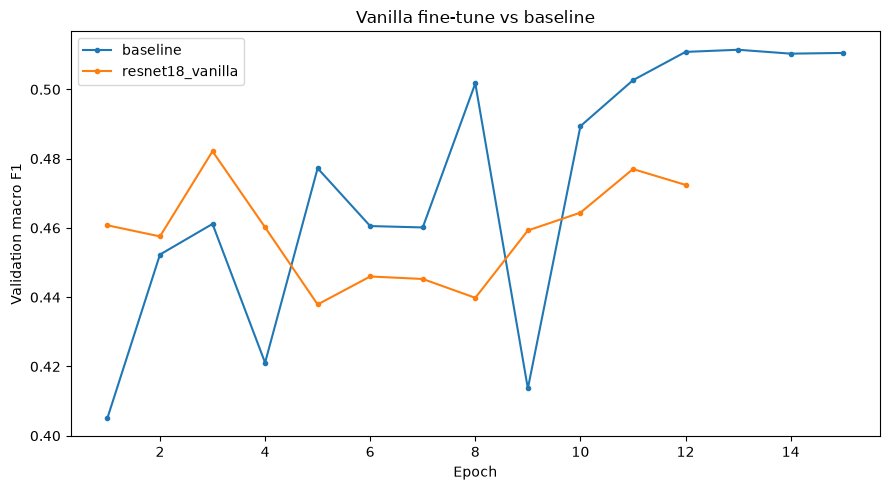

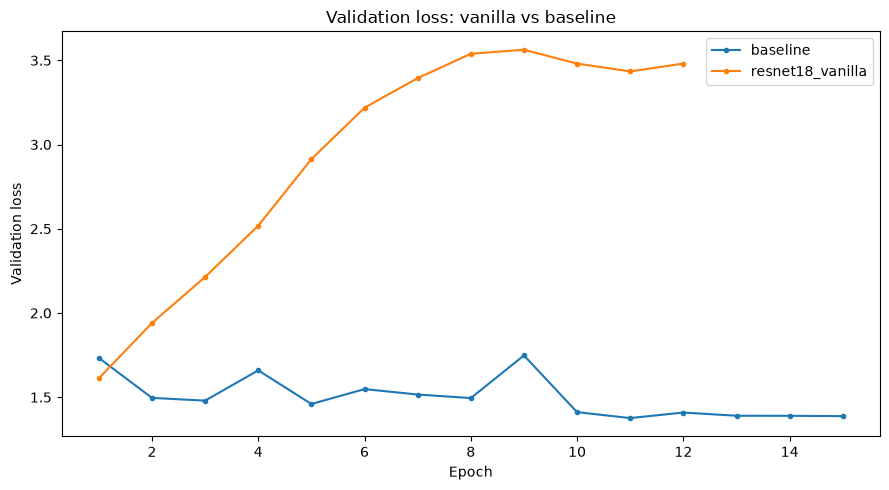

vanilla: best F1 0.4821 (epoch 3), final train_loss 0.0023


In [2]:
plot_runs(['baseline', 'resnet18_vanilla'], 'val_f1',
          'Vanilla fine-tune vs baseline', 'Validation macro F1')
plot_runs(['baseline', 'resnet18_vanilla'], 'val_loss',
          'Validation loss: vanilla vs baseline', 'Validation loss')
h = history('resnet18_vanilla')
print(f"vanilla: best F1 {h['val_f1'].max():.4f} (epoch {int(h.loc[h['val_f1'].idxmax(), 'epoch'])}), "
      f"final train_loss {h['train_loss'].iloc[-1]:.4f}")

Перша епоха виглядає добре - 0.46, baseline стільки набирав п'ять епох. Але далі overfitting: train_loss падає до 0.002, мережа фактично вивчила train напам'ять, val_loss росте з 1.6 до 3.5. Підйом на останніх епохах - не навчання, просто lr впав майже до нуля і модель перестала стрибати.

Причина: вікна одного треку перекриваються і дуже схожі між собою, тому ефективно незалежних прикладів не 153k, а близько 14k (кількість треків). Для 11M параметрів цього мало - запам'ятати виходить простіше, ніж узагальнити.

## SpecAugment + заморозка

Пробуємо прибрати overfitting. SpecAugment: при кожному читанні вікна випадкові смуги частот і шматки часу зануляються, тому те саме вікно щоепохи виглядає інакше і запам'ятати його не виходить. Додатково заморожені layer1-2 - ранні шари претрену з універсальними фільтрами, які нема сенсу перевчати.

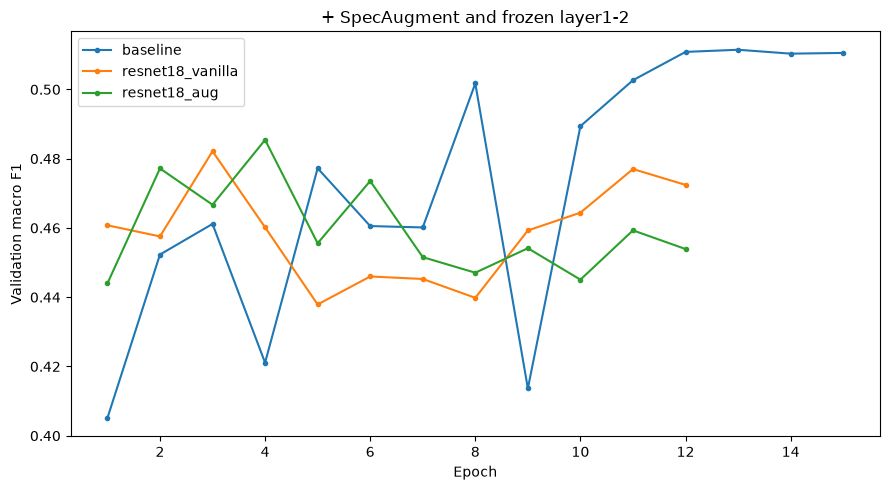

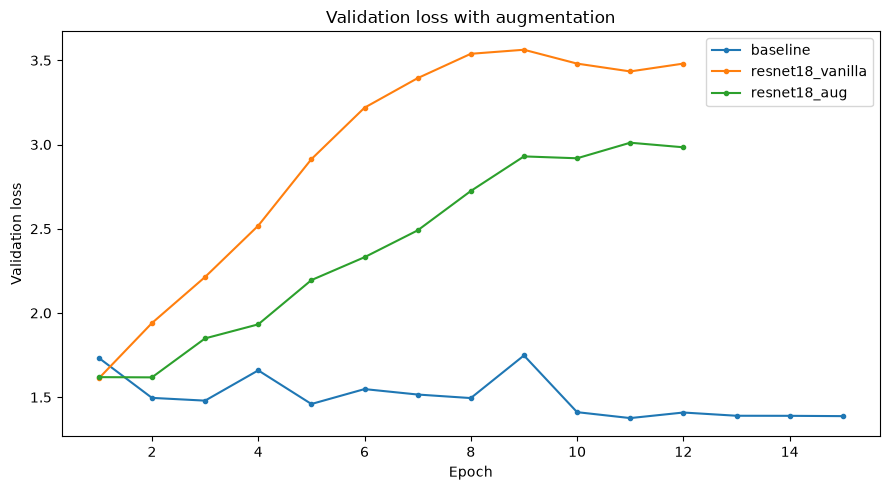

aug: best F1 0.4854 (epoch 4), final train_loss 0.1824


In [3]:
plot_runs(['baseline', 'resnet18_vanilla', 'resnet18_aug'], 'val_f1',
          '+ SpecAugment and frozen layer1-2', 'Validation macro F1')
plot_runs(['baseline', 'resnet18_vanilla', 'resnet18_aug'], 'val_loss',
          'Validation loss with augmentation', 'Validation loss')
h = history('resnet18_aug')
print(f"aug: best F1 {h['val_f1'].max():.4f} (epoch {int(h.loc[h['val_f1'].idxmax(), 'epoch'])}), "
      f"final train_loss {h['train_loss'].iloc[-1]:.4f}")

val_loss росте вдвічі повільніше і прогін нормально доживає до кінця, але пік майже не змінився: 0.485 проти 0.482. Baseline все ще попереду.

## Mixup + label smoothing

Додаємо ще два способи: mixup 0.3 (тренування на сумішах пар вікон зі змішаними мітками - такий train неможливо вивчити напам'ять) і label smoothing 0.1 (штраф за надто впевнені передбачення).

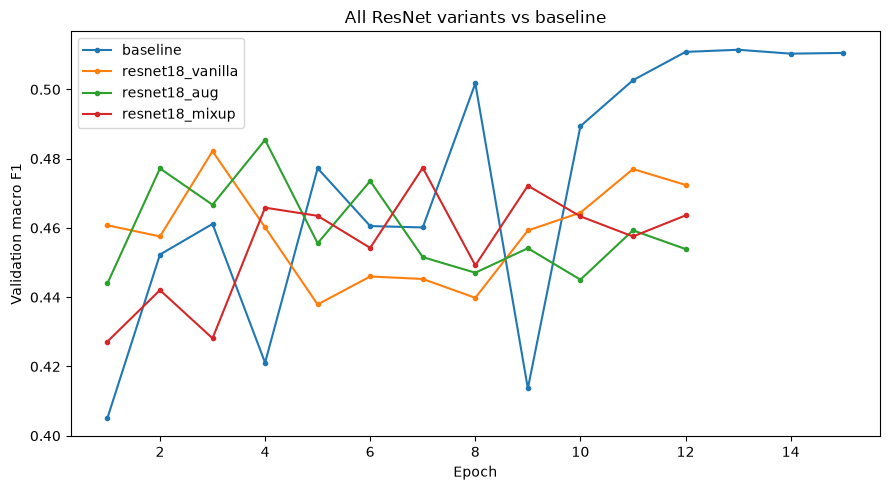

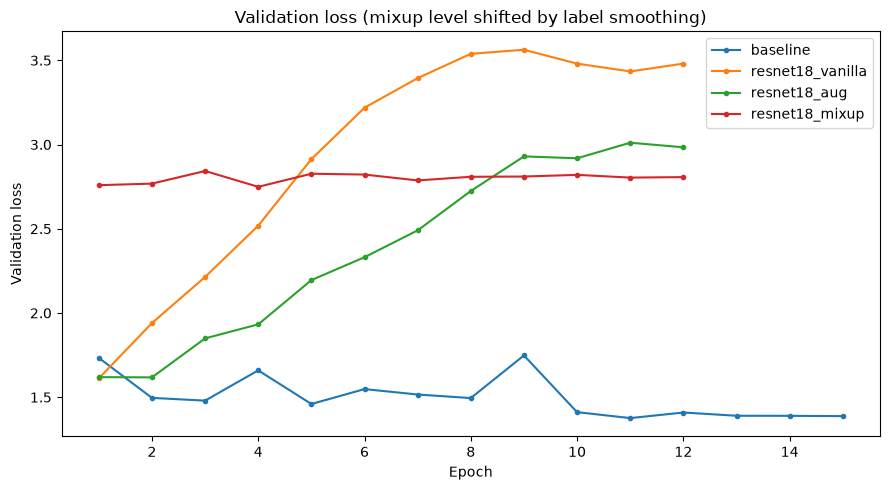

,epochs,best_val_f1,best_epoch,final_train_loss
baseline,15.0,0.5115,13.0,0.8453
resnet18_vanilla,12.0,0.4821,3.0,0.0023
resnet18_aug,12.0,0.4854,4.0,0.1824
resnet18_mixup,12.0,0.4774,7.0,1.8656


In [4]:
RESNETS = ['resnet18_vanilla', 'resnet18_aug', 'resnet18_mixup']
plot_runs(['baseline'] + RESNETS, 'val_f1',
          'All ResNet variants vs baseline', 'Validation macro F1')
# mixup val_loss is shifted up by label smoothing in the criterion --
# compare trends, not absolute levels
plot_runs(['baseline'] + RESNETS, 'val_loss',
          'Validation loss (mixup level shifted by label smoothing)', 'Validation loss')
summary = pd.DataFrame({
    name: {'epochs': len(h), 'best_val_f1': h['val_f1'].max(),
           'best_epoch': int(h.loc[h['val_f1'].idxmax(), 'epoch']),
           'final_train_loss': h['train_loss'].iloc[-1]}
    for name in ['baseline'] + RESNETS for h in [history(name)]
}).T
summary.round(4)

Overfitting зник - val_loss рівний усі 12 епох (його абсолютний рівень вищий через label smoothing, порівнювати можна тільки тренд). Але пік знову не виріс: 0.477.

Разом: три варіанти з різною регуляризацією дали 0.482, 0.485 і 0.477. Регуляризація міняє форму кривої, але не максимум. Тобто обмеження не в тренуванні, а в даних: ImageNet-фічі слабо переносяться на спектрограми (це не звичайні зображення - осі різні за змістом, нема інваріантності по частоті), а ~14k незалежних прикладів з неточними жанровими мітками для такої моделі мало.

## Порівняння по треках

Метрика апки - по треках (середнє ймовірностей 11 вікон) плюс top-3 accuracy: апка показує розподіл жанрів, і важливо, щоб правильний жанр був хоча б у трійці.

In [5]:
results = {}
for name in ['baseline'] + RESNETS:
    results[name] = evaluate_track_level(name)
    print(f'{name}: ok')
comparison = pd.DataFrame(results).T
comparison.round(4)

baseline: ok


resnet18_vanilla: ok


resnet18_aug: ok


resnet18_mixup: ok


,best_epoch,win_f1,track_acc,track_f1,track_top3_acc
baseline,13.0,0.5115,0.6233,0.5557,0.8523
resnet18_vanilla,3.0,0.4821,0.5881,0.5166,0.8284
resnet18_aug,4.0,0.4854,0.6114,0.5259,0.8409
resnet18_mixup,7.0,0.4774,0.5909,0.5198,0.7625


Baseline попереду за всіма метриками: 0.623/0.556 проти 0.611/0.526 у найкращого ResNet. У mixup top-3 просів до 0.76 - label smoothing розмазує розподіл і псує ранжування, тож для апки цей чекпоінт найгірший, хоч тренувався найстабільніше.

Transfer learning тут не окупився.

Окреме спостереження: ResNet-у аугментація помітно допомагала, а baseline тренувався без неї, хоча розрив train/val у нього теж є (0.85 проти 1.39). Логічно дати SpecAugment і йому.

## Baseline + SpecAugment

Та сама SmallCNN з тим самим протоколом, але з SpecAugment і 25 епохами замість 15 - з аугментацією train складніший і на плато модель виходить довше.

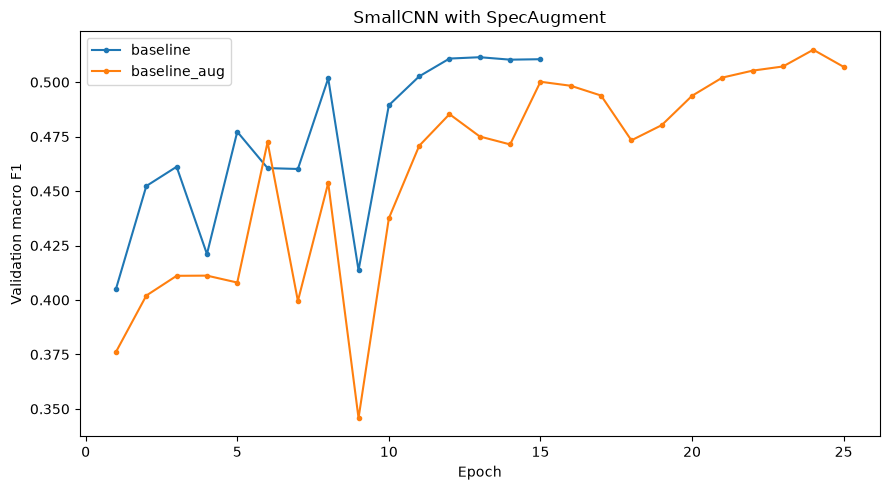

baseline_aug: best F1 0.5149 (epoch 24) over 25 epochs


,best_epoch,win_f1,track_acc,track_f1,track_top3_acc
baseline,13.0,0.5115,0.6233,0.5557,0.8523
resnet18_vanilla,3.0,0.4821,0.5881,0.5166,0.8284
resnet18_aug,4.0,0.4854,0.6114,0.5259,0.8409
resnet18_mixup,7.0,0.4774,0.5909,0.5198,0.7625
baseline_aug,24.0,0.5149,0.6273,0.5478,0.8438


In [6]:
done = ((RUNS_DIR / 'baseline_aug' / 'history.csv').exists()
        and len(history('baseline_aug')) >= 25)
if done:
    plot_runs(['baseline', 'baseline_aug'], 'val_f1',
              'SmallCNN with SpecAugment', 'Validation macro F1')
    h = history('baseline_aug')
    print(f"baseline_aug: best F1 {h['val_f1'].max():.4f} "
          f"(epoch {int(h.loc[h['val_f1'].idxmax(), 'epoch'])}) over {len(h)} epochs")
    if (RUNS_DIR / 'baseline_aug' / 'best.pt').exists():
        results['baseline_aug'] = evaluate_track_level('baseline_aug')
        display(pd.DataFrame(results).T.round(4))
else:
    print('baseline_aug: still training, re-run this notebook when it finishes')

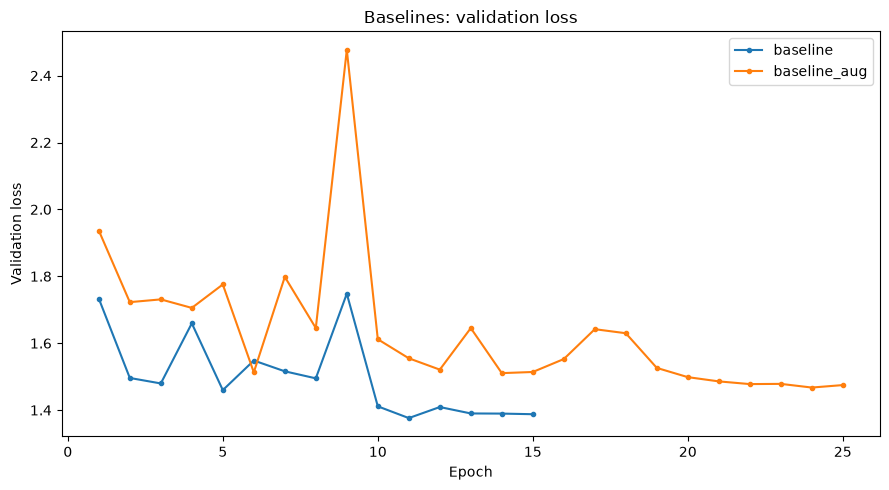

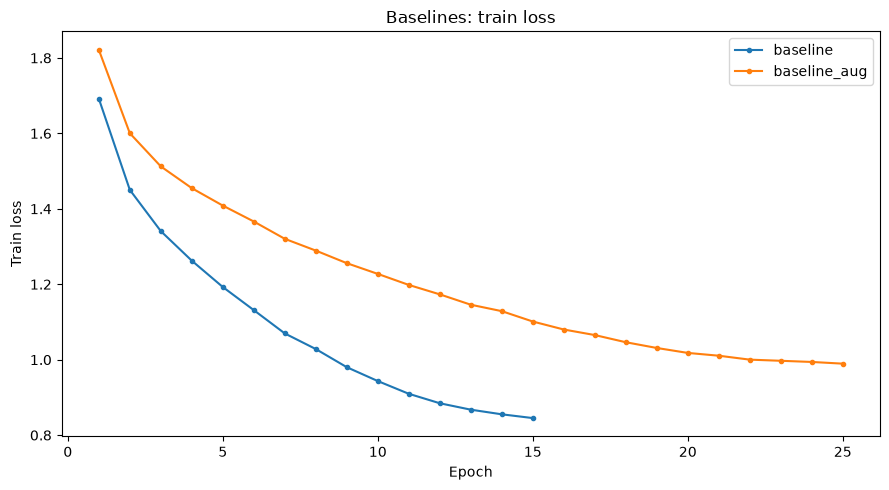

In [7]:
plot_runs(['baseline', 'baseline_aug'], 'val_loss',
          'Baselines: validation loss', 'Validation loss')
plot_runs(['baseline', 'baseline_aug'], 'train_loss',
          'Baselines: train loss', 'Train loss')

In [8]:
# Per-class track recall: whom exactly the augmentation helped
def track_predictions(name):
    ckpt = torch.load(RUNS_DIR / name / 'best.pt', map_location='mps', weights_only=False)
    val = SpectrogramWindows('../../data/spectrograms', 'validation', normalize=ckpt['normalize'])
    model = build_model(ckpt.get('model_name', 'small_cnn'), len(val.classes)).to('mps')
    model.load_state_dict(ckpt['model'])
    model.eval()
    probs = []
    with torch.no_grad():
        for x, _ in DataLoader(val, batch_size=256):
            probs.append(torch.softmax(model(x.to('mps')), dim=1).cpu())
    probs = torch.cat(probs).numpy()
    track_pos = np.array([pos for pos, _ in val.items])
    track_probs = np.stack([probs[track_pos == p].mean(axis=0)
                            for p in range(len(val.track_ids))])
    return val, val.track_labels, track_probs.argmax(axis=1)

val, true_b, pred_b = track_predictions('baseline')
_, true_a, pred_a = track_predictions('baseline_aug')
recalls = pd.DataFrame({
    'baseline': {val.classes[c]: (pred_b[true_b == c] == c).mean()
                 for c in range(len(val.classes))},
    'baseline_aug': {val.classes[c]: (pred_a[true_a == c] == c).mean()
                     for c in range(len(val.classes))},
})
recalls['diff'] = recalls['baseline_aug'] - recalls['baseline']
recalls.sort_values('diff', ascending=False).round(2)

,baseline,baseline_aug,diff
International,0.74,0.79,0.06
Pop,0.11,0.17,0.06
Instrumental,0.34,0.37,0.03
Jazz,0.33,0.36,0.03
Electronic,0.63,0.64,0.01
Experimental,0.53,0.53,0.00
Classical,0.90,0.90,0.00
Old-Time / Historic,0.76,0.76,0.00
Soul-RnB,0.22,0.22,0.00
Spoken,0.83,0.83,0.00


Результат неоднозначний.

Що покращилось: window F1 0.5149 проти 0.5115 (нарешті хоч хтось перебив чистий baseline), track accuracy 0.6273 проти 0.6233, і головне - train_loss на фініші 0.99 проти 0.85, тобто розрив train/val майже закрився: модель перестала витрачати ємність на запам'ятовування. По класах видно, кому це допомогло: Pop +0.06, International +0.06, Instrumental і Jazz +0.03 - якраз слабкі розмиті класи.

Що погіршилось: track macro-F1 0.5478 проти 0.5557. Майже весь мінус сидить в одному класі - Country впав з 0.44 до 0.22. Але у валідації Country всього 18 треків, тобто це різниця в 4 треки: на таких обсягах recall по класу - величина шумна, і робити з неї висновки не можна.

Разом: обидва baseline-варіанти практично рівні, різниця в межах шуму малих класів. На користь baseline_aug - кращі window-метрики, вища track accuracy і менший overfitting (більше шансів, що результат повториться на test), плюс модель тренована бути стійкою до часткової відсутності частот - ближче до умов живого захоплення аудіо в апці. Фінальний вибір зроблбю після test прогону.